# Burn severity in Rhodes, Greece (2023)

**Note:** This example is based on the _Introduction to Geospatial Raster and Vector Data with Python_ tutorial available [here](https://carpentries-incubator.github.io/geospatial-python/).

## Settings

### Packages

In [2]:
## List packages
pkgs <- c("rstac", "sf", "lubridate", "terra", "dplyr")

## Install missing packages
pkgs_installed <- pkgs %in% rownames(installed.packages())
if (any(pkgs_installed == FALSE)) install.packages(pkgs[!pkgs_installed])

## Load packages
invisible(lapply(pkgs, library, character.only = TRUE))

### Plotting options

In [3]:
options(repr.plot.width  =  12,
        repr.plot.height =   8,
        repr.plot.res    = 150)

### Custom functions

In [ ]:
## Convert dates to RFC3339 format
date2rfc3339 <- function(x) format(as_datetime(x), "%Y-%m-%dT%H:%M:%SZ")

## Select and download STAC assets
stac_download <- function(endpoint, collection, limit = 100,
                          start_date, end_date, target_date = NULL,
                          bbox = NULL, roi_path = NULL, thresh_cloud = NULL,
                          asset_names = NULL, out_path = tempdir()) {

    ### Load packages
    library(sf)
    library(rstac)

    ### Format date range
    daterange <- paste(lapply(c(start_date, end_date), FUN = date2rfc3339), collapse = "/")

    ### Perform initial dataset search query
    search <- stac(endpoint) |>
      stac_search(collections = collection,
                  datetime    = daterange,
                  limit       = limit)
    
    if(!is.null(bbox)) { search <- stac_search(search, bbox = bbox) }
    if(!is.null(roi_path)) { search <- stac_search(search, intersects = st_read(roi_path, quiet = TRUE)) }

    ### (Sub)select and fetch items
    items <- post_request(search)
    if(!is.null(thresh_cloud)) {
        items <- post_request(search)
        suppressWarnings(items <- items_filter(items, properties$`eo:cloud_cover` < thresh_cloud))
    }
    items <- items_fetch(items, progress = FALSE)
    if(!is.null(asset_names)) {
        items <- assets_select(items, asset_names = asset_names)
    }
    if(!is.null(target_date)) {
        target_date <- date2rfc3339(target_date)
        items <- items_select(items, selection = which(items_datetime(items) == as.Date(target_date)))
    }

    ### Download assets
    assets_json <- assets_download(items       = items,
                                   asset_names = asset_names,
                                   output_dir  = out_path,
                                   overwrite   = TRUE,
                                   use_gdal    = FALSE,
                                   progress    = FALSE)
}

### Parameters

In [52]:
## STAC endpoint URL
cons_endpoint <- "https://earth-search.aws.element84.com/v1"

## Dataset collection ID
param_collection <- "sentinel-2-l2a"

## Path to the file defining the region-of-interest
param_roi_path <- "data/rois/wf_rhodes_2023.gpkg"

## Target coordinate reference system code
param_crs_t <- "EPSG:32635"

## Start and end dates
param_date_start <- "2023-07-01"
param_date_end <- "2023-08-31"

## Pre- and post-fire dates
param_date_pre <- "2023-07-08"
param_date_post <- "2023-08-27"

## Cloud cover threshold
param_thresh_cloud <- 30

## Asset codes
param_bands <- c("nir08", "swir22")

## Path to the directory to save outputs
param_dir_out <- tempdir()
if (!dir.exists(param_dir_out)) dir.create(param_dir_out)

## Region of interest

### Import and reproject boundaries

In [57]:
## Rhodes
rhodes <- "data/rois/rhodes.gpkg" |>
  st_read(quiet = TRUE) |>
  st_as_sf() |>
  st_transform(crs = st_crs(4326))
rhodes_sv <- project(vect(rhodes), param_crs_t)

## Burned area
roi <- param_roi_path |>
  st_read(quiet = TRUE) |>
  st_as_sf() |>
  st_transform(crs = st_crs(4326))
roi_sv <- project(vect(roi), param_crs_t)

### Visualize region of interest

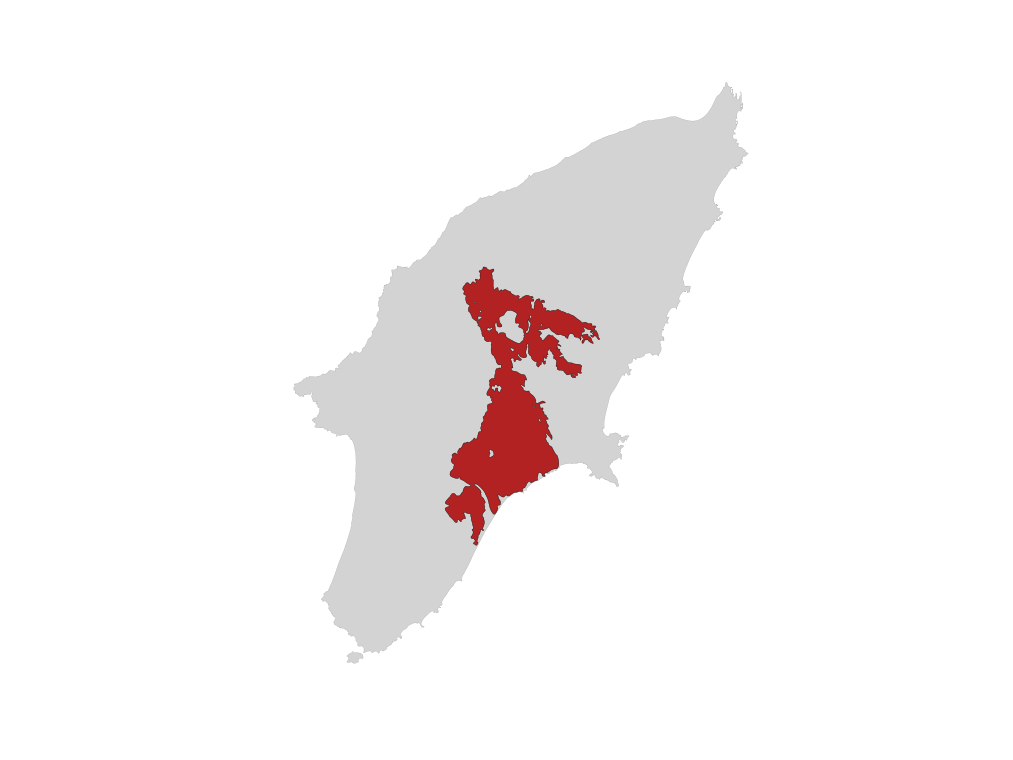

In [58]:
plot(rhodes$geom, col = "lightgray", lwd = 0.1)
plot(roi$geom, col = "firebrick", lwd = 0.5, add = TRUE)

## Data downloading

### Select and download pre-fire images

In [ ]:
# STAC Download Prefire Image
# NaaVRE:
#  cell:
#   outputs:
#    - dl_files_pre: String
#   cons:
#    - cons_endpoint: String
#   params:
#    - param_collection: String
#    - param_date_start: String
#    - param_date_end: String
#    - param_roi_path: String
#    - param_thresh_cloud: Integer
#    - param_date_pre: String
#    - param_bands: List
#    - param_dir_out: List
#   dependencies:
#    - name: sf
#    - name: rstac
# ...

dl_files_pre <- stac_download(endpoint     = cons_endpoint,
                              collection   = param_collection,
                              limit        = 100,
                              start        = param_date_start,
                              end          = param_date_end,
                              roi_path     = "data/rois/rhodes.gpkg",
                              asset_names  = param_bands,
                              target_date  = param_date_pre,
                              out_path     = param_dir_out)

In [8]:
# List results
items_as_tibble(dl_files_pre)

# A tibble: 3 × 41
  constellation created    datetime earthsearch:boa_offs…¹ earthsearch:payload_…² `earthsearch:s3_path`
  <chr>         <chr>      <chr>    <lgl>                  <chr>                  <chr>                
1 sentinel-2    2023-07-0… 2023-07… TRUE                   roda-sentinel2/workfl… s3://sentinel-cogs/s…
2 sentinel-2    2023-07-0… 2023-07… TRUE                   roda-sentinel2/workfl… s3://sentinel-cogs/s…
3 sentinel-2    2023-07-0… 2023-07… TRUE                   roda-sentinel2/workfl… s3://sentinel-cogs/s…
# ℹ abbreviated names: ¹​`earthsearch:boa_offset_applied`, ²​`earthsearch:payload_id`
# ℹ 35 more variables: `eo:cloud_cover` <dbl>, `grid:code` <chr>, instruments <chr>,
#   `mgrs:grid_square` <chr>, `mgrs:latitude_band` <chr>, `mgrs:utm_zone` <int>, platform <chr>,
#   `processing:software` <list>, `proj:epsg` <int>, `s2:cloud_shadow_percentage` <dbl>,
#   `s2:dark_features_percentage` <dbl>, `s2:datastrip_id` <chr>, `s2:datatake_id` <chr>,
#   `s2:datata

### Select and download pre-fire images

In [ ]:
# STAC Download Postfire Image
# NaaVRE:
#  cell:
#   outputs:
#    - dl_files_post: String
#   cons:
#    - cons_endpoint: String
#   params:
#    - param_collection: String
#    - param_date_start: String
#    - param_date_end: String
#    - param_roi_path: String
#    - param_thresh_cloud: Integer
#    - param_date_post: String
#    - param_bands: List
#    - param_dir_out: List
#   dependencies:
#    - name: sf
#    - name: rstac
# ...

dl_files_post <- stac_download(endpoint     = cons_endpoint,
                               collection   = param_collection,
                               limit        = 100,
                               start        = param_date_start,
                               end          = param_date_end,
                               roi_path     = "data/rois/rhodes.gpkg",
                               asset_names  = param_bands,
                               target_date  = param_date_post,
                               out_path     = param_dir_out)

In [10]:
# List results
items_as_tibble(dl_files_post)

# A tibble: 3 × 41
  constellation created    datetime earthsearch:boa_offs…¹ earthsearch:payload_…² `earthsearch:s3_path`
  <chr>         <chr>      <chr>    <lgl>                  <chr>                  <chr>                
1 sentinel-2    2023-08-2… 2023-08… TRUE                   roda-sentinel2/workfl… s3://sentinel-cogs/s…
2 sentinel-2    2023-08-2… 2023-08… TRUE                   roda-sentinel2/workfl… s3://sentinel-cogs/s…
3 sentinel-2    2023-08-2… 2023-08… TRUE                   roda-sentinel2/workfl… s3://sentinel-cogs/s…
# ℹ abbreviated names: ¹​`earthsearch:boa_offset_applied`, ²​`earthsearch:payload_id`
# ℹ 35 more variables: `eo:cloud_cover` <dbl>, `grid:code` <chr>, instruments <chr>,
#   `mgrs:grid_square` <chr>, `mgrs:latitude_band` <chr>, `mgrs:utm_zone` <int>, platform <chr>,
#   `processing:software` <list>, `proj:epsg` <int>, `s2:cloud_shadow_percentage` <dbl>,
#   `s2:dark_features_percentage` <dbl>, `s2:datastrip_id` <chr>, `s2:datatake_id` <chr>,
#   `s2:datata

## List downloaded files

### List all downloaded files

In [ ]:
dl_files <- list.files(path = param_dir_out,
                       pattern = "*.tif",
                       full.names = TRUE,
                       recursive = TRUE)
print(dl_files)

 [1] "/tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/B12.tif"
 [2] "/tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/B8A.tif"
 [3] "/tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/B12.tif"
 [4] "/tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/B8A.tif"
 [5] "/tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A/B12.tif"
 [6] "/tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A/B8A.tif"
 [7] "/tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A/B12.tif"
 [8] "/tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A/B8A.tif"
 [9] "/tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/PA/2023/7/S2A_35SPA_20230708_0_L2A/B12.tif"
[10] "/tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/PA/2023/7/S2A_35SPA_20230708_0_L2A/B8A.tif"
[11] "/tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/PA/2023/8/S2A_35SPA_20230827_0_L

### Build table with all properties

In [ ]:
dl_files_sep <- strsplit(dl_files, split = "/")
dl_files_df <- cbind(dl_files, as.data.frame(do.call(rbind, lapply(dl_files_sep, rbind))))
names(dl_files_df) <- c("path", "root", "dir", "subdir", "collection", "zone",
                        "area", "tile", "year", "month", "name", "band")
dl_files_df

                                                                                   path root dir
1  /tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/B12.tif      tmp
2  /tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/B8A.tif      tmp
3  /tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/B12.tif      tmp
4  /tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/B8A.tif      tmp
5  /tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A/B12.tif      tmp
6  /tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A/B8A.tif      tmp
7  /tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A/B12.tif      tmp
8  /tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A/B8A.tif      tmp
9  /tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/PA/2023/7/S2A_35SPA_20230708_0_L2A/B12.tif      tmp
10 /tmp/RtmpUeqTZi/sentinel-s2

### Apply grouping to pre-fire images

In [ ]:
pre_list <- filter(dl_files_df, month == "7")
print(pre_list$path)

[1] "/tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/B12.tif"
[2] "/tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/B8A.tif"
[3] "/tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A/B12.tif"
[4] "/tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A/B8A.tif"
[5] "/tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/PA/2023/7/S2A_35SPA_20230708_0_L2A/B12.tif"
[6] "/tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/PA/2023/7/S2A_35SPA_20230708_0_L2A/B8A.tif"


### Apply grouping to post-fire images

In [ ]:
post_list <- filter(dl_files_df, month == "8")
print(post_list$path)

[1] "/tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/B12.tif"
[2] "/tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/B8A.tif"
[3] "/tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A/B12.tif"
[4] "/tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A/B8A.tif"
[5] "/tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/PA/2023/8/S2A_35SPA_20230827_0_L2A/B12.tif"
[6] "/tmp/RtmpUeqTZi/sentinel-s2-l2a-cogs/35/S/PA/2023/8/S2A_35SPA_20230827_0_L2A/B8A.tif"


## Image preprocessing

### Mosaic (merge) different tiles

The three scenes/tiles have to be merged into one image for each of pre- and post-fire:

In [15]:
## Merge tiles for pre-fire images
s2_pre_path <- paste0(param_dir_out, "/s2_pre.tif")
merge(x = rast(filter(pre_list, tile == "NA")$path),
      y = rast(filter(pre_list, tile == "NV")$path),
      z = rast(filter(pre_list, tile == "PA")$path),
      filename = s2_pre_path, overwrite = TRUE)
gc()

          used (Mb) gc trigger  (Mb) max used  (Mb)
Ncells 1745357 93.3    3448715 184.2  3448715 184.2
Vcells 3013350 23.0    8388608  64.0  5766394  44.0

In [16]:
## Merge tiles for post-fire images
s2_post_path <- paste0(param_dir_out, "/s2_post.tif")
merge(x = rast(filter(post_list, tile == "NA")$path),
      y = rast(filter(post_list, tile == "NV")$path),
      z = rast(filter(post_list, tile == "PA")$path),
      filename = s2_post_path, overwrite = TRUE)
gc()

          used (Mb) gc trigger  (Mb) max used  (Mb)
Ncells 1746119 93.3    3448715 184.2  3448715 184.2
Vcells 3015114 23.1    8388608  64.0  5766394  44.0

### Crop pre-fire image

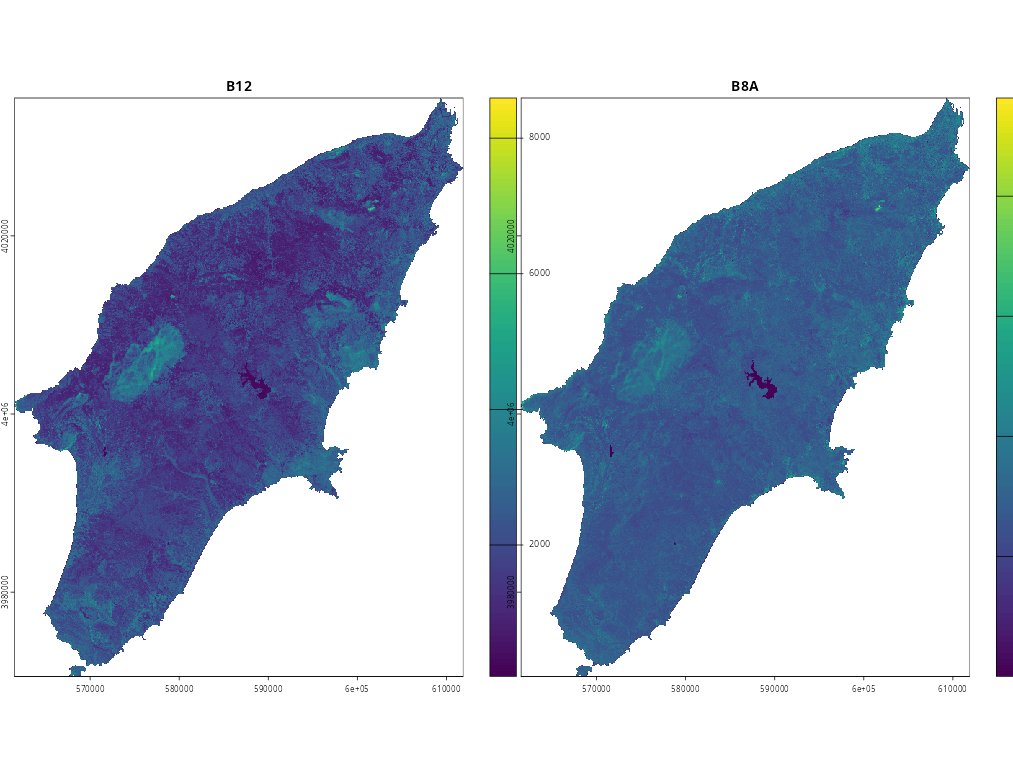

In [59]:
s2_pre_path_c <- paste0(param_dir_out, "/s2_pre_c.tif")
crop(x = rast(s2_pre_path), y = rhodes_sv, mask = TRUE,
     filename = s2_pre_path_c, overwrite = TRUE)
gc()

plot(rast(s2_pre_path_c))

### Crop post-fire image

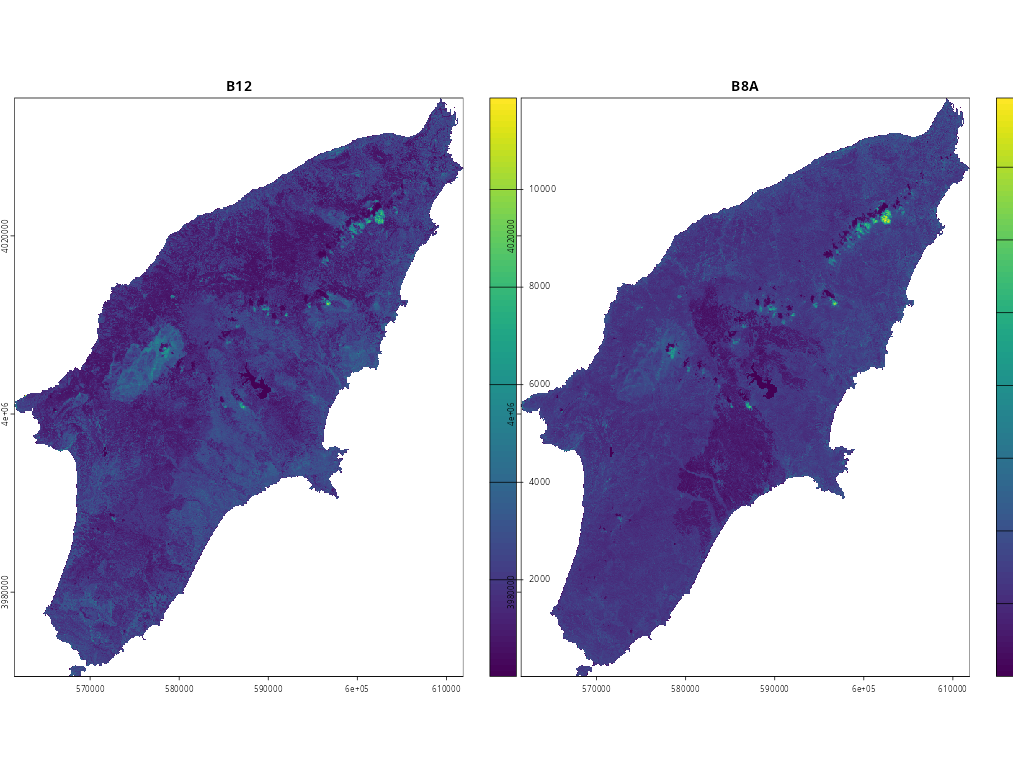

In [60]:
s2_post_path_c <- paste0(param_dir_out, "/s2_post_c.tif")
crop(x = rast(s2_post_path), y = rhodes_sv, mask = TRUE,
     filename = s2_post_path_c, overwrite = TRUE)
gc()

plot(rast(s2_post_path_c))

## Burn severity assessment

The Normalized Burn Ratio (NBR) can be calculated, from the Sentinel-2 bands 8 (near-infrared, NIR) and 12 (shortwave-infrared, SWIR), using the following expression:

$`NBR = {(NIR - SWIR) \over{(NIR + SWIR)}}`$

### Compute pre-fire NBR

In [23]:
s2_pre_path_nbr <- paste0(param_dir_out, "/s2_pre_nbr.tif")
lapp(x = rast(s2_pre_path_c),
     fun = \(B8A, B12) ((B8A - B12) / (B8A + B12)),
     usenames = TRUE, cores = 3,
     filename = s2_pre_path_nbr, overwrite = TRUE)
gc()

           used  (Mb) gc trigger  (Mb)  max used  (Mb)
Ncells  2392097 127.8   12659982 676.2  10614552 566.9
Vcells 18320530 139.8   90103941 687.5 112629926 859.3

### Compute post-fire NBR

In [24]:
s2_post_path_nbr <- paste0(param_dir_out, "/s2_post_nbr.tif")
lapp(x = rast(s2_post_path_c),
     fun = \(B8A, B12) ((B8A - B12) / (B8A + B12)),
     usenames = TRUE, cores = 3,
     filename = s2_post_path_nbr, overwrite = TRUE)
gc()

           used  (Mb) gc trigger  (Mb)  max used  (Mb)
Ncells  2392103 127.8   13055345 697.3  10614552 566.9
Vcells 18320538 139.8   86563784 660.5 112629926 859.3

### Visualize NBR maps

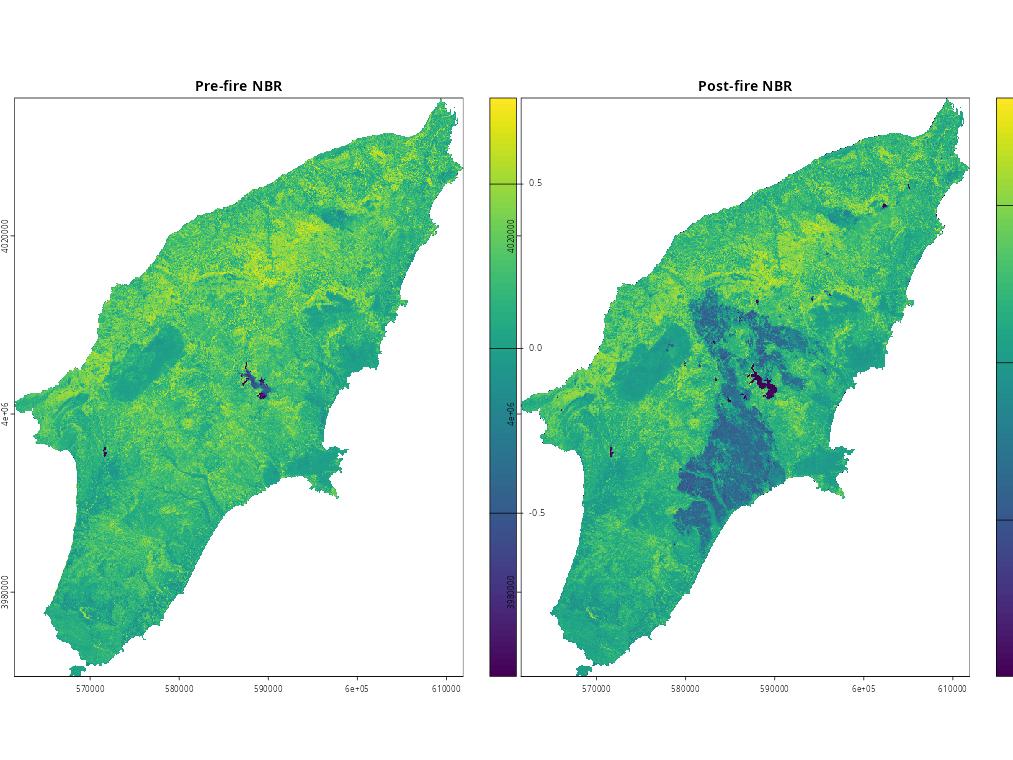

In [25]:
s2_nbr <- c(rast(s2_pre_path_nbr), rast(s2_post_path_nbr))
names(s2_nbr) <- c("Pre-fire NBR", "Post-fire NBR")
plot(s2_nbr)

### Calculate dNBR

Burn severity can be mapped using Delta-NBR, calculated as follows:

$`dNBR = {NBR_{pre} - NBR_{post}}`$

In [68]:
s2_dnbr_path <- paste0(param_dir_out, "/s2_dnbr.tif")
xapp(x = rast(s2_pre_path_nbr), y = rast(s2_post_path_nbr),
     fun = \(x, y) (x - y), filename = s2_dnbr_path, overwrite = TRUE)
gc()

            used  (Mb) gc trigger   (Mb)  max used   (Mb)
Ncells   3446388 184.1   33565729 1792.7  41187388 2199.7
Vcells 101542251 774.8  228861198 1746.1 190236794 1451.4

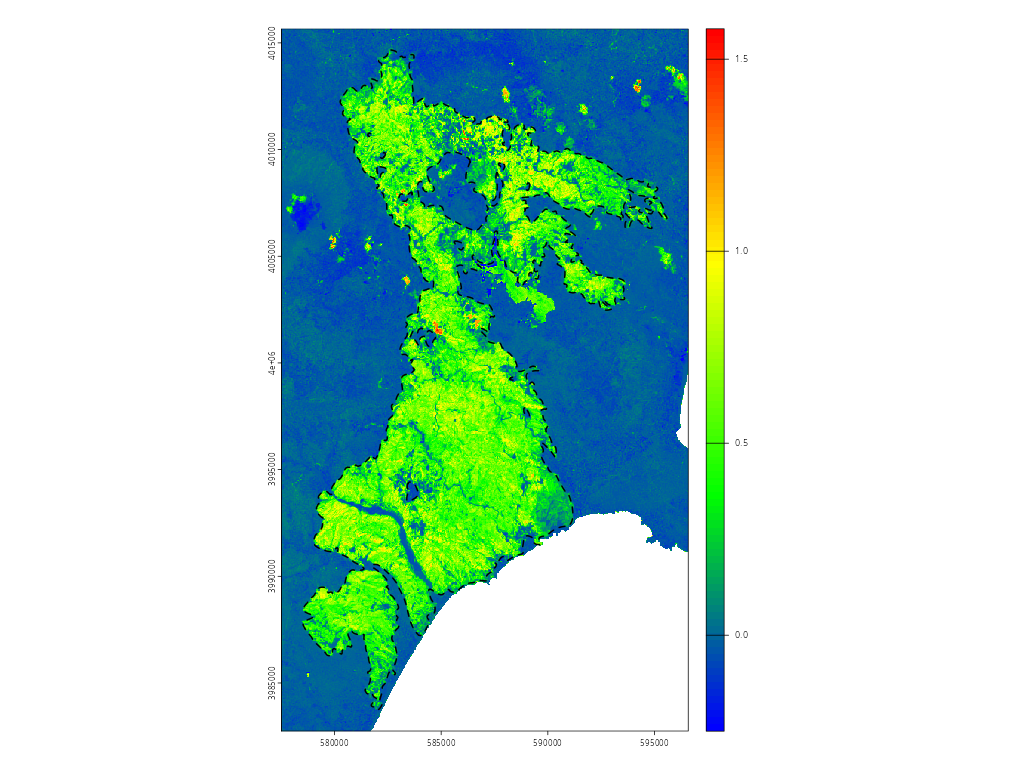

In [111]:
s2_dnbr <- rast(s2_dnbr_path) |>
  crop(buffer(roi_sv, 1000), mask = FALSE)
s2_dnbr |>
  clamp(lower = -0.25, upper = 2) |>
  plot(col = map.pal("bgyr", n = 100))
plot(roi_sv, lty = 2, lwd = 2, add = TRUE)

### Analyze distribution

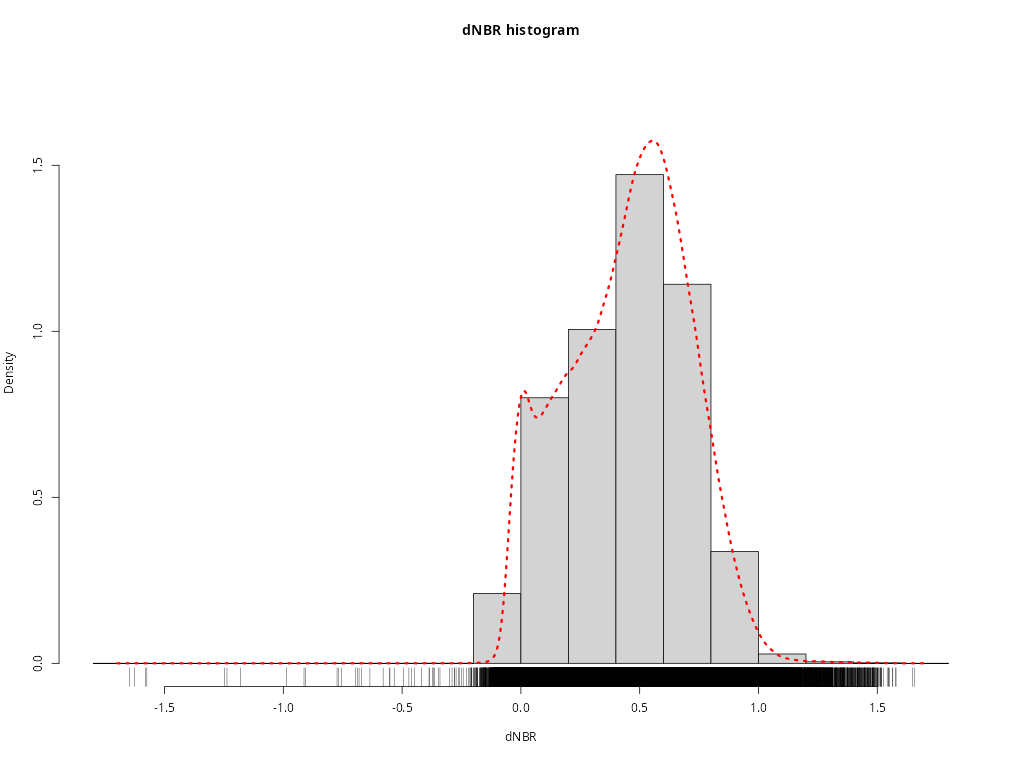

In [117]:
dnbr_vals <- rast(s2_dnbr_path) |>
  crop(roi_sv, mask = TRUE) |>
  values() |>
  na.omit() |>
  as.vector()
write.csv(dnbr_vals, "out/tables/dnbr_rhodes.csv", row.names = FALSE)

hist(dnbr_vals, prob = TRUE,
     ylim = c(0, 1.75), #xlim = c(-0.2, 1),
     main = "dNBR histogram", xlab = "dNBR")
lines(density(dnbr_vals),
      col = "red", lwd = 3, lty = 3)
rug(jitter(dnbr_vals), lwd = 0.5)